In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

RAW_DATA_PATH = Path("../data/raw")

In [2]:
sorted([file.name for file in RAW_DATA_PATH.glob("*.csv")])

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [3]:
orders = pd.read_csv(
    RAW_DATA_PATH / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

order_items = pd.read_csv(
    RAW_DATA_PATH / "olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"],
)

customers = pd.read_csv(
    RAW_DATA_PATH / "olist_customers_dataset.csv"
)

products = pd.read_csv(
    RAW_DATA_PATH / "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    RAW_DATA_PATH / "olist_sellers_dataset.csv"
)

payments = pd.read_csv(
    RAW_DATA_PATH / "olist_order_payments_dataset.csv"
)

In [4]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "payments": payments,
}

for name, df in tables.items():
    print(f"\n{'=' * 60}")
    print(f"{name.upper()}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    display(df.head(3))
    display(df.info())


ORDERS: 99,441 rows × 8 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


None


ORDER_ITEMS: 112,650 rows × 7 columns


...

None


PAYMENTS: 103,886 rows × 5 columns


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


None

In [5]:
orders["order_status"].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

delivered_orders.shape

(96478, 8)

In [7]:
delivered_orders["late_delivery"] = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
).astype(int)

delivered_orders[
    [
        "order_id",
        "order_approved_at",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "late_delivery",
    ]
].head(10)

,order_id,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26,0
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 22:10:13,2017-07-26 10:57:55,2017-08-01,0
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:22:11,2017-05-26 12:55:51,2017-06-07,0
8,76c6e866289321a7c93b82b54852dc33,2017-01-25 02:50:47,2017-02-02 14:08:10,2017-03-06,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 12:05:32,2017-08-16 17:14:30,2017-08-23,0
10,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:50:18,2017-05-29 11:18:31,2017-06-07,0


In [8]:
delivered_orders["late_delivery"].value_counts()

late_delivery
0    88652
1     7826
Name: count, dtype: int64

In [9]:
target_summary = (
    delivered_orders["late_delivery"]
    .value_counts()
    .rename(index={0: "On time", 1: "Late"})
    .to_frame("orders")
)

target_summary["percentage"] = (
    target_summary["orders"] / target_summary["orders"].sum() * 100
).round(2)

target_summary

,orders,percentage
late_delivery,,
On time,88652,91.89
Late,7826,8.11


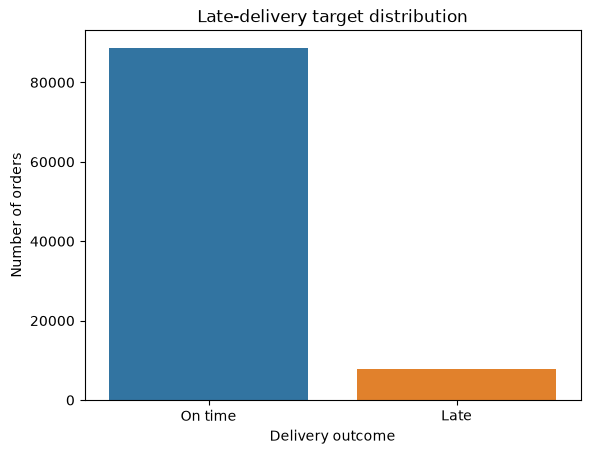

In [10]:
sns.countplot(
    data=delivered_orders,
    x="late_delivery",
    hue="late_delivery",
    legend=False
)

plt.xticks([0, 1], ["On time", "Late"])
plt.title("Late-delivery target distribution")
plt.xlabel("Delivery outcome")
plt.ylabel("Number of orders")
plt.show()